In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Load all CSV files from the data folder
data_path = '../data/'
csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]

print(f"Found {len(csv_files)} files:")
for f in sorted(csv_files):
    size_mb = os.path.getsize(os.path.join(data_path, f)) / (1024*1024)
    print(f"  {f} ({size_mb:.1f} MB)")

# Load and combine all files
dfs = []
for f in sorted(csv_files):
    df_temp = pd.read_csv(os.path.join(data_path, f), low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()  # remove whitespace from column names
    dfs.append(df_temp)
    print(f"  Loaded {f}: {df_temp.shape[0]} rows")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Found 8 files:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv (73.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv (73.3 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv (55.6 MB)
  Monday-WorkingHours.pcap_ISCX.csv (168.7 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv (79.3 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv (49.6 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv (128.8 MB)
  Wednesday-workingHours.pcap_ISCX.csv (214.7 MB)
  Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225745 rows
  Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286467 rows
  Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: 191033 rows
  Loaded Monday-WorkingHours.pcap_ISCX.csv: 529918 rows
  Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288602 rows
  Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170366 rows
  Loaded Tuesday-WorkingHours.pcap_ISCX.csv: 445909 rows
  Loaded Wednesday-workingHours.pcap_IS

In [12]:
# What does the data look like?
print("First 3 rows:")
print(df.head(3).to_string())
print(f"\nColumn names ({len(df.columns)}):")
print(list(df.columns))

First 3 rows:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean  Fwd IAT Std  Fwd IAT Max  Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean  Bwd IAT Std  Bwd IAT Max  Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Min Packet Length  Max Packet Length  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG Flag Count  CWE Flag Count  ECE Flag Count  Down/Up Ratio  Average Packet Size  Avg Fwd Segment Size  Avg Bwd Segment Size  Fwd

In [13]:
# What attack types exist?
print(f"Unique labels: {df['Label'].nunique()}\n")
label_counts = df['Label'].value_counts()
print(label_counts)

Unique labels: 15

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [14]:
# Data quality check
print("Missing values:")
missing = df.isnull().sum()
print(f"  Total: {missing.sum()}")
if missing.sum() > 0:
    print(f"  Columns with nulls: {missing[missing > 0].to_dict()}")

print(f"\nInfinite values:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[numeric_cols]).sum().sum()
print(f"  Total: {inf_count}")

print(f"\nDuplicates: {df.duplicated().sum()}")

print(f"\nData types:")
print(df.dtypes.value_counts())

Missing values:
  Total: 1358
  Columns with nulls: {'Flow Bytes/s': 1358}

Infinite values:
  Total: 4376

Duplicates: 308381

Data types:
int64      54
float64    24
str         1
Name: count, dtype: int64


In [15]:
# CLEANING — CICIDS2017 has known data quality issues

print(f"Before cleaning: {df.shape[0]} rows")

# 1. Drop duplicates
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape[0]} rows ({308381} removed)")

# 2. Replace infinite values with NaN, then drop all NaN rows
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
print(f"After removing NaN/Inf rows: {df.shape[0]} rows")

# 3. Verify clean
print(f"\nRemaining nulls: {df.isnull().sum().sum()}")
print(f"Remaining infs: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"\nFinal dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Before cleaning: 2830743 rows
After removing duplicates: 2522362 rows (308381 removed)
After removing NaN/Inf rows: 2520798 rows

Remaining nulls: 0
Remaining infs: 0

Final dataset: 2520798 rows, 79 columns


Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Benign: 2095057 (83.1%)
Attack: 425741 (16.9%)


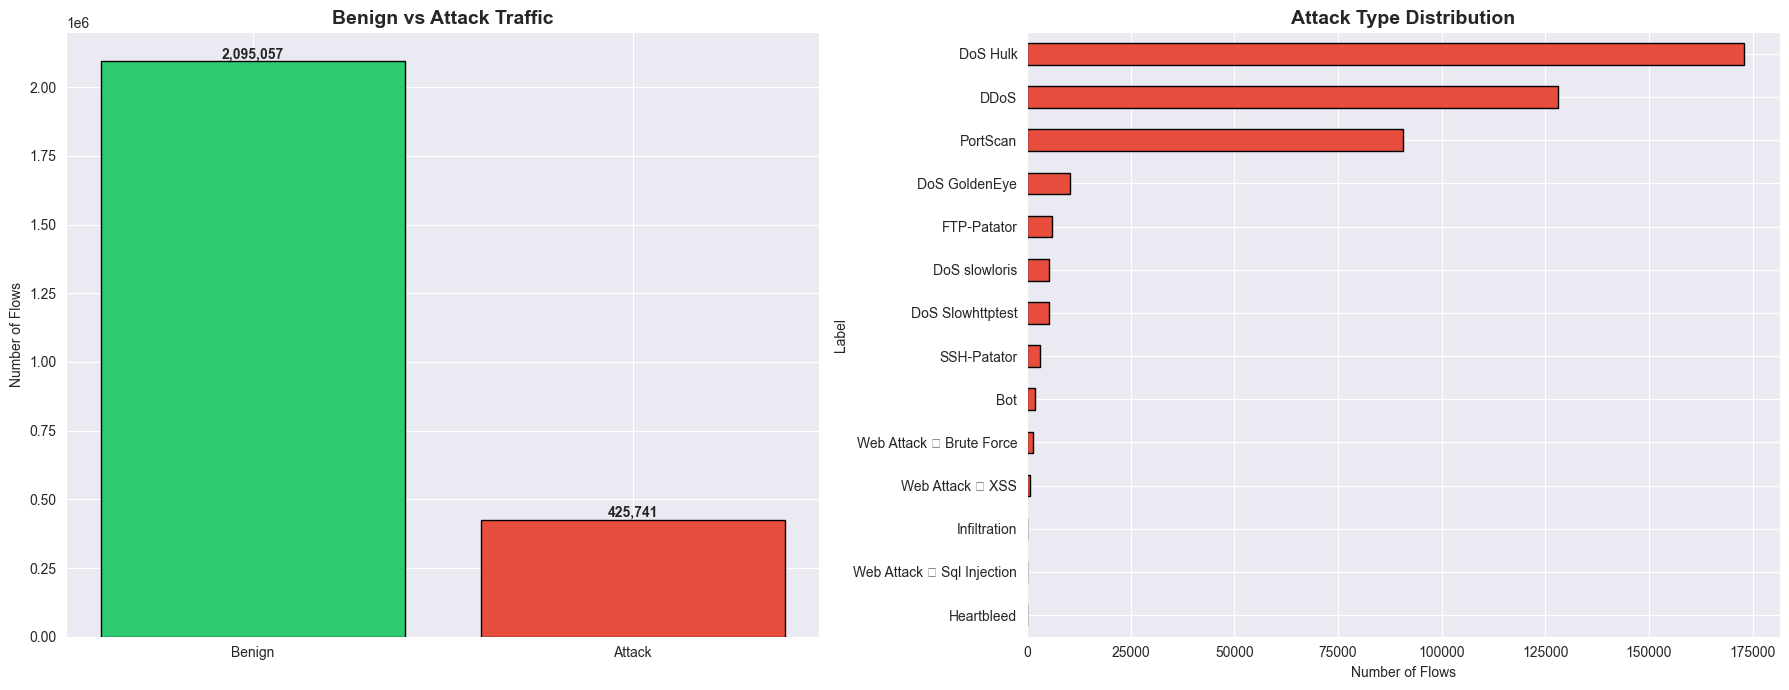

In [16]:
# Label distribution after cleaning
label_counts = df['Label'].value_counts()
print(label_counts)
print(f"\nBenign: {label_counts['BENIGN']} ({label_counts['BENIGN']/len(df)*100:.1f}%)")
print(f"Attack: {len(df) - label_counts['BENIGN']} ({(len(df) - label_counts['BENIGN'])/len(df)*100:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: benign vs attack
benign = label_counts['BENIGN']
attack = len(df) - benign
axes[0].bar(['Benign', 'Attack'], [benign, attack],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Benign vs Attack Traffic', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Flows')
for i, v in enumerate([benign, attack]):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', fontweight='bold')

# Right: attack types breakdown (excluding benign)
attack_counts = label_counts[label_counts.index != 'BENIGN']
attack_counts.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Attack Type Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Flows')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
attack_map = {
    'BENIGN': 'Benign',

    # DoS/DDoS — all denial of service variants
    'DoS Hulk': 'DoS/DDoS',
    'DoS GoldenEye': 'DoS/DDoS',
    'DoS slowloris': 'DoS/DDoS',
    'DoS Slowhttptest': 'DoS/DDoS',
    'DDoS': 'DoS/DDoS',
    'Heartbleed': 'DoS/DDoS',

    # Brute Force — credential stuffing attacks
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',

    # Web Attack — application layer attacks
    'Web Attack \x96 Brute Force': 'Web Attack',
    'Web Attack \x96 XSS': 'Web Attack',
    'Web Attack \x96 Sql Injection': 'Web Attack',

    # Reconnaissance — network scanning
    'PortScan': 'Reconnaissance',

    # Botnet — command and control traffic
    'Bot': 'Botnet',

    # Infiltration — keeping despite 36 samples (documented limitation)
    'Infiltration': 'Infiltration'
}

df['attack_category'] = df['Label'].map(attack_map)

# Check for unmapped labels
unmapped = df[df['attack_category'].isna()]['Label'].unique()
if len(unmapped) > 0:
    print(f"WARNING — unmapped labels: {unmapped}")
    for label in unmapped:
        print(f"  Repr: {repr(label)}")
else:
    print("All labels mapped successfully!")
    print(f"\nCategory distribution:")
    print(df['attack_category'].value_counts())

WARNING — unmapped labels: <StringArray>
['Web Attack � Brute Force', 'Web Attack � XSS', 'Web Attack � Sql Injection']
Length: 3, dtype: str
  Repr: 'Web Attack � Brute Force'
  Repr: 'Web Attack � XSS'
  Repr: 'Web Attack � Sql Injection'


In [18]:
# Fix the Web Attack labels — use the actual strings from the data
# Instead of guessing the encoding, just map based on what contains "Web Attack"

df['attack_category'] = df['Label'].apply(lambda x:
    'Benign' if x == 'BENIGN'
    else 'DoS/DDoS' if x in ['DoS Hulk', 'DoS GoldenEye', 'DoS slowloris', 'DoS Slowhttptest', 'DDoS', 'Heartbleed']
    else 'Brute Force' if x in ['FTP-Patator', 'SSH-Patator']
    else 'Web Attack' if 'Web Attack' in x
    else 'Reconnaissance' if x == 'PortScan'
    else 'Botnet' if x == 'Bot'
    else 'Infiltration' if x == 'Infiltration'
    else 'Unknown'
)

# Verify
unknown = df[df['attack_category'] == 'Unknown'].shape[0]
print(f"Unmapped: {unknown}")
print(f"\nCategory distribution:")
print(df['attack_category'].value_counts())

Unmapped: 0

Category distribution:
attack_category
Benign            2095057
DoS/DDoS           321770
Reconnaissance      90694
Brute Force          9150
Web Attack           2143
Botnet               1948
Infiltration           36
Name: count, dtype: int64


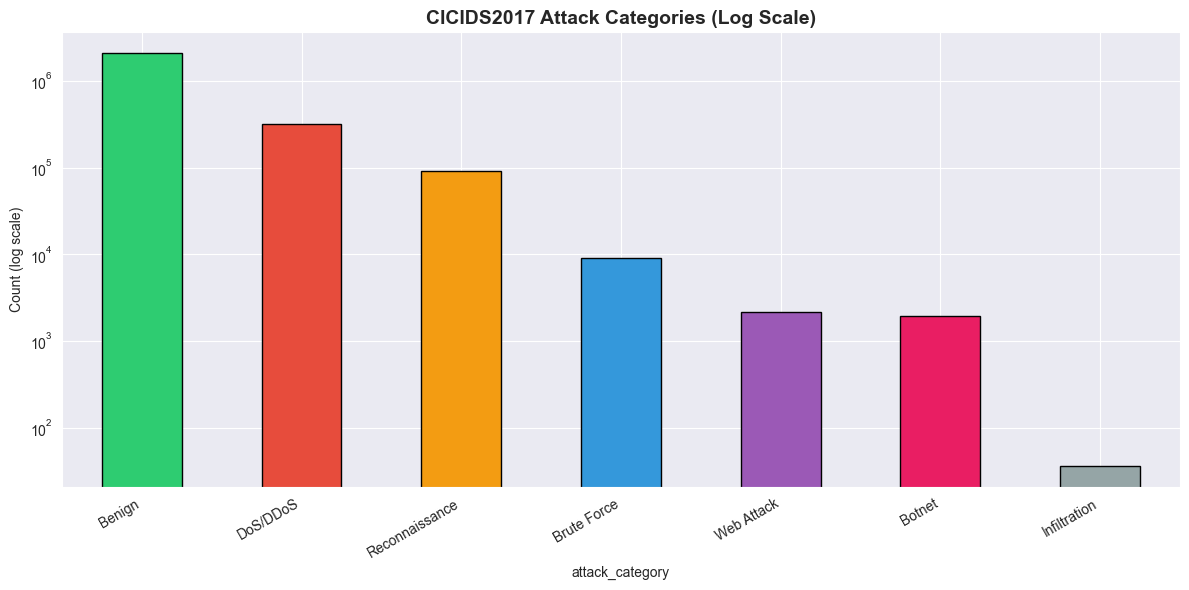


Size ratio vs Infiltration (smallest):
  Benign              : 58,196x
  DoS/DDoS            : 8,938x
  Reconnaissance      : 2,519x
  Brute Force         : 254x
  Web Attack          : 60x
  Botnet              : 54x
  Infiltration        : 1x


In [19]:
# Visualize categories
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'Benign': '#2ecc71', 'DoS/DDoS': '#e74c3c', 'Reconnaissance': '#f39c12',
    'Brute Force': '#3498db', 'Web Attack': '#9b59b6', 'Botnet': '#e91e63',
    'Infiltration': '#95a5a6'
}

cat_counts = df['attack_category'].value_counts()
cat_counts.plot(kind='bar', color=[colors[c] for c in cat_counts.index],
                edgecolor='black', ax=ax, logy=True)
ax.set_title('CICIDS2017 Attack Categories (Log Scale)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count (log scale)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Size ratios vs smallest class
print("\nSize ratio vs Infiltration (smallest):")
for cat in cat_counts.index:
    ratio = cat_counts[cat] / cat_counts['Infiltration']
    print(f"  {cat:20s}: {ratio:,.0f}x")

In [20]:
# Save cleaned data for Phase 2
df.to_csv('../data/cicids2017_clean.csv', index=False)
print(f"Saved: {df.shape[0]} rows to cicids2017_clean.csv")
print("\nPhase 1 complete!")

Saved: 2520798 rows to cicids2017_clean.csv

Phase 1 complete!
